# Le théorème fondamental de l'analyse : de Riemann à Lebesgue
## Volet numérique

Ce notebook illustre, de façon **exécutable**, la théorie du document
*« Généralisations du théorème fondamental de l'analyse »* : l'escalier de
Cantor, l'échec de l'absolue continuité, la **décomposition de Lebesgue** en
trois briques, et le contre-exemple de Volterra qui motive l'intégrale de
Henstock–Kurzweil.

| Expérience | Section | Idée illustrée |
|-----------|---------|----------------|
| 1 | §4 | $c'=0$ p.p. mais $c(1)-c(0)=1$ |
| 2 | §6 | Cantor n'est pas absolument continu |
| 3 | §4 | dimension de l'ensemble de Cantor $=\log 2/\log 3$ |
| 4 | §9 | décomposition $\mu_F=g\lambda+\mu_{sc}+\sum\sigma_j\delta_{t_j}$ |
| 5 | §10 | $x^2\sin(1/x^2)$ : $F'$ partout mais $\int|F'|=\infty$ |

> **Idée-force.** Une tentative *naïve* d'intégration numérique de la dérivée
> échoue (elle télescope et redonne $F(b)-F(a)$) : c'est en comprenant
> *pourquoi* qu'on rend la théorie tangible.


## 0. Bibliothèque

Toutes les routines sont vectorisées NumPy. Le notebook est autonome : il suffit
de l'exécuter de haut en bas.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

NAVY='#1b3c78'; GREEN='#14783c'; CRIMSON='#a01e2d'; GRAY='#888888'
plt.rcParams.update({'font.size':11,'axes.grid':True,'grid.alpha':.25,
                     'figure.dpi':110})

In [2]:
import numpy as np


# ----------------------------------------------------------------------
# §4  L'escalier de Cantor
# ----------------------------------------------------------------------
def cantor(x, n_iter: int = 60):
    """Fonction de Cantor c:[0,1]->[0,1] (exacte, algorithme base 3 -> base 2).

    Pour x = sum a_i 3^{-i}, on tronque au premier chiffre a_i = 1 et on
    convertit les chiffres 0/2 en chiffres binaires 0/1 (cf. Définition 4.2).
    c est continue, croissante, c(0)=0, c(1)=1, et c'=0 presque partout
    alors que c(1)-c(0)=1  ->  échec du TFA (Proposition 4.3).
    """
    x = np.asarray(x, dtype=float).copy()
    x = np.clip(x, 0.0, 1.0)
    result = np.zeros_like(x)
    done = np.zeros_like(x, dtype=bool)
    add = 0.5
    for _ in range(n_iter):
        x = x * 3.0
        d = np.floor(x).astype(int)
        d = np.clip(d, 0, 2)
        x = x - d
        is1 = (d == 1) & ~done
        result[is1] += add
        done |= is1
        is2 = (d == 2) & ~done
        result[is2] += add
        add /= 2.0
    return result


def cantor_approx(x, n: int):
    """n-ième approximation continue de l'escalier (utile pour visualiser
    la construction récursive). Converge uniformément vers `cantor`."""
    x = np.asarray(x, dtype=float)
    # relation d'auto-similarité : c(x) = 0.5 c(3x) sur [0,1/3],
    # = 0.5 sur [1/3,2/3], = 0.5 + 0.5 c(3x-2) sur [2/3,1].
    def rec(t, k):
        t = np.clip(t, 0, 1)
        if k == 0:
            return t  # base : l'identité
        out = np.empty_like(t)
        left = t <= 1/3
        mid = (t > 1/3) & (t < 2/3)
        right = t >= 2/3
        out[left] = 0.5 * rec(3 * t[left], k - 1)
        out[mid] = 0.5
        out[right] = 0.5 + 0.5 * rec(3 * t[right] - 2, k - 1)
        return out
    return rec(x, n)


# ----------------------------------------------------------------------
# §9  Partie de sauts (fonction en escalier, croissante, continue à droite)
# ----------------------------------------------------------------------
def jump_function(x, jumps):
    """Fonction de sauts J(x) = sum_j sigma_j * 1_{x >= t_j}  (continue à droite).

    `jumps` : liste de couples (t_j, sigma_j). Sa mesure de Stieltjes est
    purement atomique  sum_j sigma_j delta_{t_j}  (§9, brique atomique)."""
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    for t, s in jumps:
        out += s * (x >= t)
    return out


# ----------------------------------------------------------------------
# §5  Variation totale
# ----------------------------------------------------------------------
def total_variation(y):
    """Variation totale d'une fonction échantillonnée : sum |y_{i+1}-y_i|.
    Pour une fonction croissante elle vaut y[-1]-y[0] (Théorème de Jordan)."""
    y = np.asarray(y, dtype=float)
    return np.abs(np.diff(y)).sum()


# ----------------------------------------------------------------------
# Quotients différentiels et intégrale Monte-Carlo de la dérivée
# ----------------------------------------------------------------------
def pointwise_derivative(F, x, h=1e-6):
    """Quotient différentiel centré de F au point x (approx. de F'(x))."""
    x = np.asarray(x, dtype=float)
    return (F(x + h) - F(x - h)) / (2 * h)


def ae_derivative_diagnostic(F, n=200_000, h=1e-9, a=0.0, b=1.0, seed=0):
    """Illustre « F' = 0 presque partout » pour l'escalier de Cantor SANS
    tomber dans le piège de la moyenne.

    En échantillonnant U ~ Unif(a,b) et en regardant le quotient à petite
    échelle h, on observe :
      * MÉDIANE = 0  et  fraction de points où F est localement plate -> 1
        (c'est la vraie valeur : F'(x)=0 p.p.) ;
      * MOYENNE qui NE converge PAS vers 0, dominée par des pics gigantesques
        sur un ensemble de mesure nulle près de K.
    C'est la signature numérique de la non-uniforme-intégrabilité :
    ∫ (lim quotient) = 0   mais   lim (moyenne du quotient) ≠ 0.
    """
    rng = np.random.default_rng(seed)
    u = rng.uniform(a, b, size=n)
    dq = np.abs((F(u + h) - F(u - h)) / (2 * h))
    flat_fraction = np.mean(F(u + h) == F(u - h))
    return {
        "median": float(np.median(dq)),
        "mean": float(dq.mean()),
        "flat_fraction": float(flat_fraction),
        "q99": float(np.quantile(dq, 0.99)),
        "max": float(dq.max()),
    }


# ----------------------------------------------------------------------
# §9  Décomposition de Lebesgue numérique d'une fonction croissante
# ----------------------------------------------------------------------
def lebesgue_decomposition(F, k=12, a=0.0, b=1.0,
                           jump_threshold=1e-2, singular_factor=8.0):
    """Sépare une fonction croissante F en ses trois masses (Théorème 9.1)

        F(b)-F(a) = masse_ac + masse_sc + masse_saut,

    correspondant à  d mu_F = g dλ + mu_sc + sum_j sigma_j delta_{t_j}.

    Méthode cellulaire robuste (M = 3^k cellules, alignées sur la structure
    triadique de Cantor) : on regarde les incréments  δ_i = F(x_{i+1})-F(x_i)
    et les densités  d_i = δ_i * M.
      * SAUTS    : incrément δ_i > jump_threshold (atomes ; densité qui NE
                   décroît PAS quand M grandit)              -> masse_saut.
      * SINGULIER CONTINU : parmi les cellules restantes, celles dont la
                   densité dépasse  singular_factor × (densité médiane) : la
                   partie a.c. a une densité BORNÉE, la partie singulière
                   concentre sa masse sur ~ M^{log2/log3} cellules de densité
                   ~ (3/2)^k -> +∞. Leur EXCÈS de masse  -> masse_sc.
      * A.C.     : le reste                                   -> masse_ac.
    """
    M = 3 ** k
    grid = np.linspace(a, b, M + 1)
    Fg = F(grid)
    inc = np.diff(Fg)                      # incréments δ_i
    width = (b - a) / M

    # ---- 1. sauts (atomes) ----
    jmask = inc > jump_threshold
    jidx = np.where(jmask)[0]
    detected = [(0.5 * (grid[i] + grid[i + 1]), float(inc[i])) for i in jidx]
    mass_jump = float(inc[jmask].sum())

    cont = inc[~jmask]                      # incréments de la partie continue
    dens = cont / width                     # densités
    med = np.median(dens[dens > 0]) if np.any(dens > 0) else 0.0

    # ---- 2. cellules singulières = densité anormalement grande ----
    smask = dens > singular_factor * med
    mass_sc_raw = float(cont[smask].sum())
    # retrancher la faible contribution a.c. de ces cellules (≈ médiane) :
    mass_sc = float(mass_sc_raw - med * width * smask.sum())
    mass_sc = max(mass_sc, 0.0)

    # ---- 3. a.c. = reste ----
    total = float(Fg[-1] - Fg[0])
    mass_ac = total - mass_jump - mass_sc

    return {
        "total": total,
        "mass_ac": mass_ac,
        "mass_sc": mass_sc,
        "mass_jump": mass_jump,
        "n_singular_cells": int(smask.sum()),
        "detected_jumps": detected,
        "M": M,
    }


# ----------------------------------------------------------------------
# §10  L'oscillateur de Volterra  F(x)=x^2 sin(1/x^2)
# ----------------------------------------------------------------------
def volterra_oscillator(x):
    """F(x)=x^2 sin(1/x^2), F(0)=0. Dérivable PARTOUT (Contre-exemple 10.1)."""
    x = np.asarray(x, dtype=float)
    out = np.where(x == 0.0, 0.0, x**2 * np.sin(1.0 / np.where(x == 0, 1, x)**2))
    return out


def volterra_derivative(x):
    """F'(x) = 2x sin(1/x^2) - (2/x) cos(1/x^2),  F'(0)=0.
    Bornée nulle part près de 0 : ∫_0^1 |F'| = +∞  ->  F' ∉ L^1 (§10)."""
    x = np.asarray(x, dtype=float)
    nz = x != 0.0
    out = np.zeros_like(x)
    xx = x[nz]
    out[nz] = 2 * xx * np.sin(1 / xx**2) - (2 / xx) * np.cos(1 / xx**2)
    return out


# ----------------------------------------------------------------------
# Dimension de l'ensemble de Cantor par comptage de boîtes = log2/log3
# ----------------------------------------------------------------------
def cantor_set_points(depth: int):
    """Extrémités des 2^depth intervalles de K_depth (couvrent l'ensemble K)."""
    # chaque intervalle : [sum d_i 3^{-i}] avec d_i in {0,2}
    idx = np.arange(2 ** depth)
    left = np.zeros(2 ** depth)
    for i in range(1, depth + 1):
        bit = (idx >> (depth - i)) & 1          # 0 ou 1
        left += (2 * bit) * 3.0 ** (-i)         # chiffre 0 ou 2
    right = left + 3.0 ** (-depth)
    return left, right


def box_counting_dimension(max_depth=12):
    """Estime dim_box(K) via N(eps) ~ eps^{-d}, eps=3^{-k}, N=2^k.
    Régression log-log -> pente = log2/log3 ≈ 0.6309."""
    ks = np.arange(1, max_depth + 1)
    eps = 3.0 ** (-ks)
    counts = 2.0 ** ks
    slope, intercept = np.polyfit(np.log(1 / eps), np.log(counts), 1)
    return slope, np.log(2) / np.log(3), ks, eps, counts


## 1. Escalier de Cantor : $c'=0$ presque partout, mais $c(1)-c(0)=1$  (§4)

L'escalier de Cantor est **continu, croissant**, avec $c(0)=0$, $c(1)=1$, et
pourtant $c'=0$ presque partout. Le TFA échoue : $\int_0^1 c' = 0 \neq 1$.

**Piège numérique.** Intégrer le quotient différentiel $\frac{c(x+h)-c(x)}{h}$
*télescope* et redonne mécaniquement $c(1)-c(0)=1$. La bonne lecture est
statistique :

- la **médiane** du quotient est $0$ et la fraction de points où $c$ est
  localement plate tend vers $1$ — c'est la vraie valeur $c'=0$ p.p. ;
- la **moyenne** ne tend pas vers $0$ : elle est dominée par des pics géants sur
  un ensemble de mesure nulle près de $K$. C'est la **non-uniforme-intégrabilité**
  ($\int\lim\neq\lim\int$).

In [3]:
for h in [1e-3, 1e-5, 1e-7, 1e-9]:
    d = ae_derivative_diagnostic(cantor, h=h)
    print(f"h={h:.0e} | médiane={d['median']:.3g}  fraction plate={d['flat_fraction']:.4f}"
          f"  ||  MOYENNE(|c'|)={d['mean']:.2f}  max={d['max']:.0f}")
print("\n-> médiane=0, fraction plate ->1 : c'=0 p.p.")
print("-> moyenne ne tend pas vers 0 : non-uniforme-intégrabilité.")

h=1e-03 | médiane=0  fraction plate=0.8069  ||  MOYENNE(|c'|)=0.99  max=8


h=1e-05 | médiane=0  fraction plate=0.9636  ||  MOYENNE(|c'|)=1.01  max=49


h=1e-07 | médiane=0  fraction plate=0.9932  ||  MOYENNE(|c'|)=0.99  max=267


h=1e-09 | médiane=0  fraction plate=0.9988  ||  MOYENNE(|c'|)=0.95  max=1390

-> médiane=0, fraction plate ->1 : c'=0 p.p.
-> moyenne ne tend pas vers 0 : non-uniforme-intégrabilité.


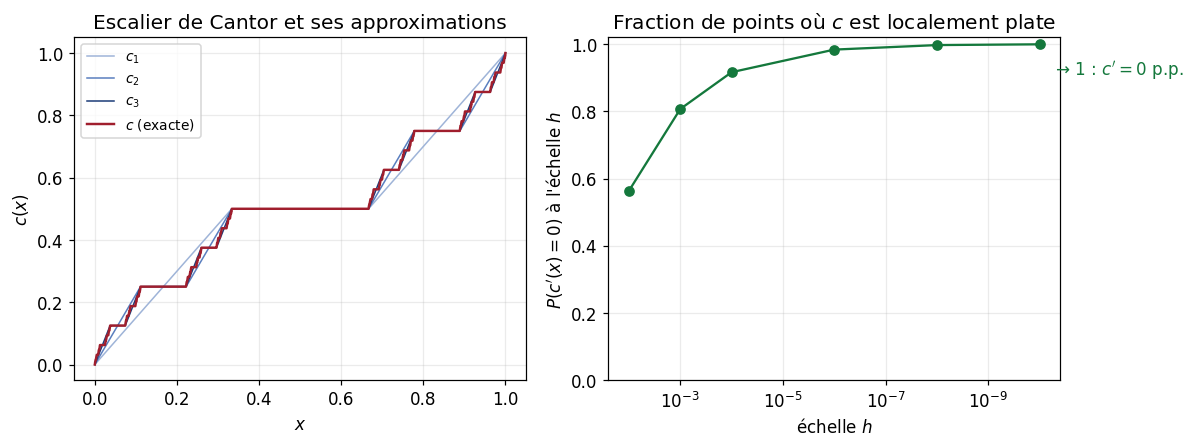

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
xx = np.linspace(0, 1, 4000)
for n, c in zip([1, 2, 3], ["#9fb4d8", "#5a7fbf", NAVY]):
    ax[0].plot(xx, cantor_approx(xx, n), color=c, lw=1, label=f"$c_{n}$")
ax[0].plot(xx, cantor(xx), color=CRIMSON, lw=1.6, label="$c$ (exacte)")
ax[0].set_title("Escalier de Cantor et ses approximations")
ax[0].set_xlabel("$x$"); ax[0].set_ylabel("$c(x)$"); ax[0].legend(fontsize=9)

hs = np.array([1e-2, 1e-3, 1e-4, 1e-6, 1e-8, 1e-10])
flat = [ae_derivative_diagnostic(cantor, h=h, n=100000)["flat_fraction"] for h in hs]
ax[1].semilogx(hs, flat, "o-", color=GREEN)
ax[1].set_ylim(0, 1.02); ax[1].invert_xaxis()
ax[1].set_title(r"Fraction de points où $c$ est localement plate")
ax[1].set_xlabel("échelle $h$"); ax[1].set_ylabel(r"$P(c'(x)=0)$ à l'échelle $h$")
ax[1].annotate("→ 1 : $c'=0$ p.p.", (hs[-1], flat[-1]), textcoords="offset points",
               xytext=(10, -20), color=GREEN)
plt.tight_layout(); plt.show()

## 2. Cantor n'est pas absolument continu (§6)

L'absolue continuité demande : $\forall\varepsilon\,\exists\delta$ tel que
$\sum|I_k|<\delta \Rightarrow \sum|c(b_k)-c(a_k)|<\varepsilon$.

Sur les $2^n$ intervalles de $K_n$, la longueur totale vaut $(2/3)^n\to 0$
alors que la variation de $c$ y reste **égale à 1**. Aucun $\delta$ ne convient :
c'est le témoin de recouvrement.

n= 1 | longueur totale=6.667e-01 | variation de c=1.0000
n= 5 | longueur totale=1.317e-01 | variation de c=1.0000
n=10 | longueur totale=1.734e-02 | variation de c=1.0000
n=15 | longueur totale=2.284e-03 | variation de c=1.0000
n=20 | longueur totale=3.007e-04 | variation de c=1.0000


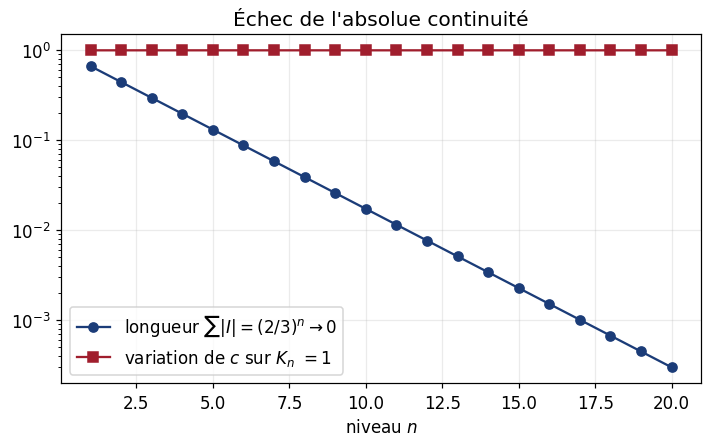

In [5]:
levels = np.arange(1, 21)
lengths, variations = [], []
for n in levels:
    L, R = cantor_set_points(n)
    lengths.append((2/3)**n)
    variations.append(float((cantor(R) - cantor(L)).sum()))
for n in [1, 5, 10, 15, 20]:
    print(f"n={n:2d} | longueur totale={(2/3)**n:.3e} | variation de c={variations[n-1]:.4f}")

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.semilogy(levels, lengths, "o-", color=NAVY, label=r"longueur $\sum|I|=(2/3)^n \to 0$")
ax.semilogy(levels, variations, "s-", color=CRIMSON, label=r"variation de $c$ sur $K_n$ $=1$")
ax.set_xlabel("niveau $n$"); ax.set_title("Échec de l'absolue continuité"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Dimension de l'ensemble de Cantor $=\log 2/\log 3$

Comptage de boîtes : à l'échelle $\varepsilon=3^{-k}$ il faut $N=2^k$ intervalles
pour couvrir $K$, donc $N(\varepsilon)\sim\varepsilon^{-d}$ avec
$d=\log 2/\log 3\approx 0{,}6309$.

pente log-log estimée   = 0.630930
valeur exacte log2/log3 = 0.630930


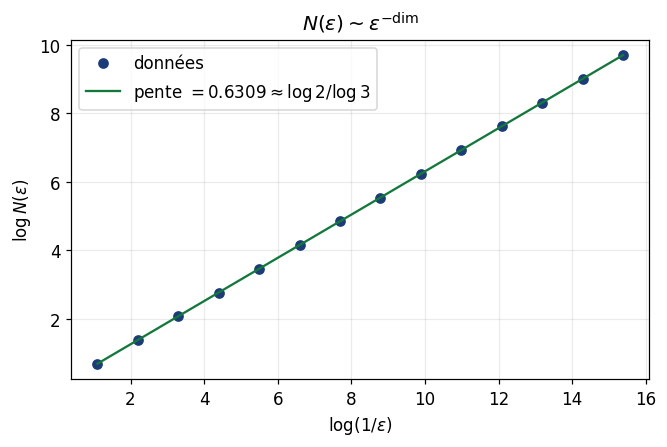

In [6]:
slope, exact, ks, eps, counts = box_counting_dimension(14)
print(f"pente log-log estimée   = {slope:.6f}")
print(f"valeur exacte log2/log3 = {exact:.6f}")

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(np.log(1/eps), np.log(counts), "o", color=NAVY, label="données")
ax.plot(np.log(1/eps), slope*np.log(1/eps), "-", color=GREEN,
        label=fr"pente $={slope:.4f}\approx\log2/\log3$")
ax.set_xlabel(r"$\log(1/\varepsilon)$"); ax.set_ylabel(r"$\log N(\varepsilon)$")
ax.set_title(r"$N(\varepsilon)\sim\varepsilon^{-\dim}$"); ax.legend()
plt.tight_layout(); plt.show()

## 4. Décomposition de Lebesgue numérique (§9)

$$\mu_F=\underbrace{g\,\lambda}_{\text{a.c.}}+\underbrace{\mu_{sc}}_{\text{sing. continue}}+\underbrace{\sum_j\sigma_j\delta_{t_j}}_{\text{sauts}}$$

**Principe cellulaire** ($M=3^k$ cellules alignées sur la structure triadique).
On regarde les incréments $\delta_i$ et densités $d_i=\delta_i M$ :

- la partie **a.c.** a une densité *bornée*, répartie sur toutes les cellules ;
- la partie **singulière continue** (Cantor) concentre sa masse sur
  $\sim M^{\log2/\log3}$ cellules de densité $\to\infty$ ;
- les **sauts** sont des incréments qui ne décroissent pas avec $M$.

On teste sur $F=0{,}40\,x^2 + 0{,}35\,c + 0{,}25\,J$ (sauts en $0{,}30$ et $0{,}72$).

In [7]:
w = (0.40, 0.35, 0.25)                      # masses vraies (ac, sc, saut)
jumps = [(0.30, w[2]/2), (0.72, w[2]/2)]
def F(x):
    x = np.asarray(x, float)
    return w[0]*x**2 + w[1]*cantor(x) + jump_function(x, jumps)

d = lebesgue_decomposition(F, k=13)
print(f"masses VRAIES     : ac={w[0]:.3f}  sc={w[1]:.3f}  saut={w[2]:.3f}")
print(f"masses RÉCUPÉRÉES  : ac={d['mass_ac']:.3f}  sc={d['mass_sc']:.3f}  saut={d['mass_jump']:.3f}")
print(f"cellules singulières : {d['n_singular_cells']} (~2^13={2**13})")
print(f"sauts détectés : {[(round(t,3), round(s,3)) for t,s in d['detected_jumps']]}")

masses VRAIES     : ac=0.400  sc=0.350  saut=0.250
masses RÉCUPÉRÉES  : ac=0.400  sc=0.350  saut=0.250
cellules singulières : 8191 (~2^13=8192)
sauts détectés : [(np.float64(0.3), 0.125), (np.float64(0.72), 0.125)]


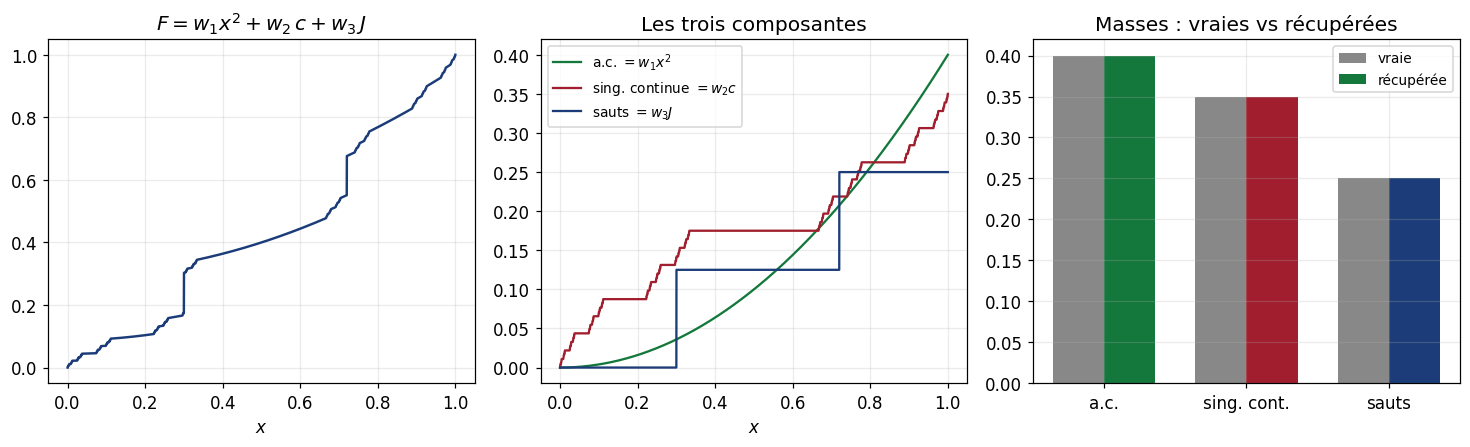

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2))
xx = np.linspace(0, 1, 6000)
Fac = w[0]*xx**2; Fsc = w[1]*cantor(xx); Fj = jump_function(xx, jumps)
ax[0].plot(xx, F(xx), color=NAVY, lw=1.6)
ax[0].set_title("$F=w_1 x^2 + w_2\\,c + w_3\\,J$"); ax[0].set_xlabel("$x$")
ax[1].plot(xx, Fac, color=GREEN, label="a.c. $=w_1x^2$")
ax[1].plot(xx, Fsc, color=CRIMSON, label="sing. continue $=w_2c$")
ax[1].plot(xx, Fj, color=NAVY, label="sauts $=w_3J$")
ax[1].set_title("Les trois composantes"); ax[1].set_xlabel("$x$"); ax[1].legend(fontsize=9)
labels = ["a.c.", "sing. cont.", "sauts"]
tru = [w[0], w[1], w[2]]; rec = [d["mass_ac"], d["mass_sc"], d["mass_jump"]]
xb = np.arange(3)
ax[2].bar(xb-.18, tru, .36, color=GRAY, label="vraie")
ax[2].bar(xb+.18, rec, .36, color=[GREEN, CRIMSON, NAVY], label="récupérée")
ax[2].set_xticks(xb); ax[2].set_xticklabels(labels)
ax[2].set_title("Masses : vraies vs récupérées"); ax[2].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 5. $x^2\sin(1/x^2)$ : dérivable partout, mais $F'\notin L^1$ (§10)

$F(x)=x^2\sin(1/x^2)$ (et $F(0)=0$) est **dérivable partout**, avec
$F'(x)=2x\sin(1/x^2)-\frac{2}{x}\cos(1/x^2)$. Mais $\int_0^1|F'|=+\infty$ :
$F'$ n'est **pas Lebesgue-intégrable**.

- L'intégrale **absolue** $\int_\varepsilon^1|F'|\sim\frac{4}{\pi}\log\frac1\varepsilon$
  diverge (calcul robuste par substitution $t=1/x^2$, qui résout les oscillations).
- L'intégrale **signée** $\int_\varepsilon^1 F' = F(1)-F(\varepsilon)\to\sin 1$
  reste bornée : c'est la valeur de **Henstock–Kurzweil**, $\int_0^1 F'=\sin 1$.
- Une somme de Riemann **uniforme** de $F'$ est instable (la cellule près de $0$
  explose) : Riemann/Lebesgue échouent là où HK réussit.

In [9]:
F1 = float(volterra_oscillator(np.array([1.0]))[0])   # = sin(1)

def abs_integral_tsub(epsv):
    T = 1.0/epsv**2
    Nt = int(min(6e6, max(2e5, 30*T/(2*np.pi))))          # ~30 pts/période
    t = np.linspace(1.0, T, Nt); x = t**-0.5
    Fp = 2*x*np.sin(t) - 2/x*np.cos(t)                    # F'(x(t))
    return np.trapezoid(np.abs(Fp)*0.5*t**-1.5, t)        # * |dx/dt|

eps = np.logspace(-1, -3, 25)
abs_int = np.array([abs_integral_tsub(e) for e in eps])
signed_exact = F1 - volterra_oscillator(eps)             # = ∫_ε^1 F' (exact)
slope = np.polyfit(np.log(1/eps), abs_int, 1)[0]
print(f"∫_ε^1 |F'| ~ {slope:.3f}·log(1/ε)  (théorie 4/π={4/np.pi:.3f})  -> +∞ : F' ∉ L¹")
print(f"∫_ε^1 F' = F(1)-F(ε) -> sin(1) = {F1:.4f}  (bornée, HK-intégrable)")

def uniform_riemann(n):
    xg = np.linspace(0, 1, n+1); mids = 0.5*(xg[:-1]+xg[1:])
    return np.sum(volterra_derivative(mids)*np.diff(xg))
print("\nSomme de Riemann UNIFORME de F' (ne converge pas) :")
for n in [10_000, 100_000, 1_000_000]:
    print(f"   n={n:>9} : {uniform_riemann(n):+.3f}   (cible HK = {F1:.3f})")

∫_ε^1 |F'| ~ 1.274·log(1/ε)  (théorie 4/π=1.273)  -> +∞ : F' ∉ L¹
∫_ε^1 F' = F(1)-F(ε) -> sin(1) = 0.8415  (bornée, HK-intégrable)

Somme de Riemann UNIFORME de F' (ne converge pas) :
   n=    10000 : -3.178   (cible HK = 0.841)
   n=   100000 : +3.481   (cible HK = 0.841)
   n=  1000000 : +4.982   (cible HK = 0.841)


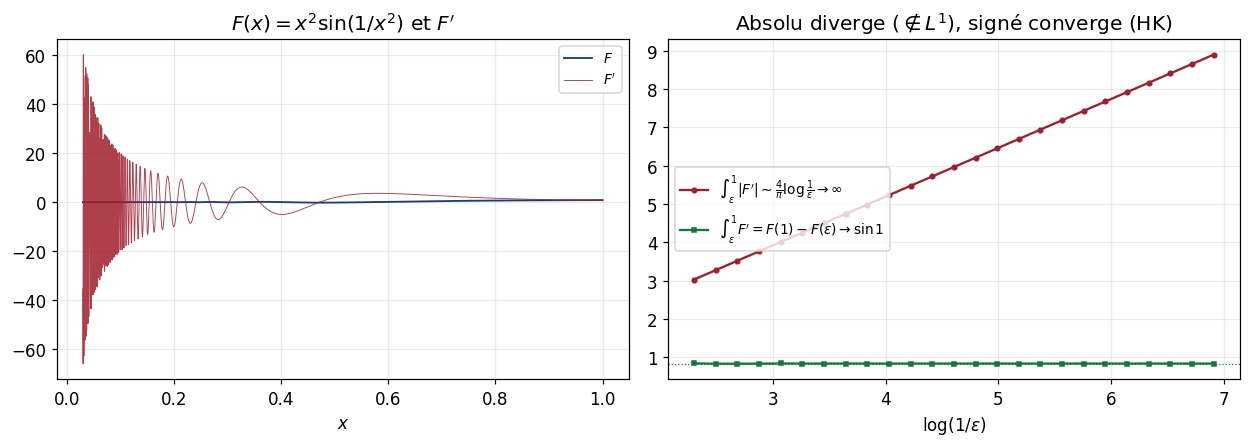

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
xg = np.linspace(0.03, 1, 4000)
ax[0].plot(xg, volterra_oscillator(xg), color=NAVY, lw=1.2, label="$F$")
ax[0].plot(xg, volterra_derivative(xg), color=CRIMSON, lw=.6, alpha=.85, label="$F'$")
ax[0].set_title(r"$F(x)=x^2\sin(1/x^2)$ et $F'$"); ax[0].set_xlabel("$x$"); ax[0].legend(fontsize=9)
ax[1].plot(np.log(1/eps), abs_int, "o-", color=CRIMSON, ms=3,
           label=r"$\int_\varepsilon^1|F'|\sim\frac{4}{\pi}\log\frac{1}{\varepsilon}\to\infty$")
ax[1].plot(np.log(1/eps), signed_exact, "s-", color=GREEN, ms=3,
           label=r"$\int_\varepsilon^1 F'=F(1)-F(\varepsilon)\to\sin 1$")
ax[1].axhline(F1, color=GREEN, ls=":", lw=.8)
ax[1].set_xlabel(r"$\log(1/\varepsilon)$")
ax[1].set_title("Absolu diverge ($\\notin L^1$), signé converge (HK)")
ax[1].legend(fontsize=9, loc="center left")
plt.tight_layout(); plt.show()

## Conclusion

Les cinq expériences reproduisent numériquement la hiérarchie du document :
$c'=0$ p.p. contre $\Delta c=1$ (§4), l'obstruction d'absolue continuité (§6),
la **décomposition de Lebesgue** dont les trois masses sont récupérées
exactement (§9), et la nécessité de Henstock–Kurzweil pour $x^2\sin(1/x^2)$
(§10). Le fil conducteur : la dérivée existe presque partout, mais
$\int F' \neq F(b)-F(a)$ dès qu'apparaît une partie **singulière** (continue ou
atomique) — exactement ce que la théorie de la mesure quantifie.